# Audit + Deduplikasi (Fase 1–3)

Satu notebook: bangun `master_raw.csv` → audit data mentah → deteksi duplikat.
Setiap citra dibaca **satu kali** (MD5, SHA-256, decode penuh, pHash sekaligus).

Tidak ada preprocessing, harmonisasi label, splitting, Spark, atau training. Duplikat **hanya ditandai** (`proposed_keep`), tidak ada yang dihapus.

## 0. Konfigurasi

In [1]:
import os, io, re, json, hashlib
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image
pd.set_option("display.width", 200, "display.max_columns", 50, "display.max_rows", 100)

ROOTS = json.loads(os.environ["ROOTS_JSON"]) if "ROOTS_JSON" in os.environ else {
    "HAM10000": "/kaggle/input/datasets/nadiraanindita/dataset-riset-ham10k",
    "ISIC2017": "/kaggle/input/datasets/nadiraanindita/dataset-riset-isic-2017",
    "ISIC2019": "/kaggle/input/datasets/nadiraanindita/dataset-riset-isic-2019"}
OUT = Path(os.environ.get("OUT_DIR", "/kaggle/working/audit_dedup")); (OUT / "figures").mkdir(parents=True, exist_ok=True)
PHASH_MAX = 4                           # jarak Hamming pHash maksimum untuk KANDIDAT near-duplicate (<= 7)
NEAR_MERGE = False                      # True = kandidat pHash ikut digabung ke grup duplikat (berisiko grup raksasa)
DHASH_MAX = None                        # mis. 10 untuk konfirmasi tambahan dHash; None = hanya pHash
PRIORITY = ["HAM10000", "ISIC2019", "ISIC2017"]   # dataset yang dipertahankan lebih dulu dalam grup duplikat
A = {}                                  # tabel audit -> disimpan sebagai audit_*.csv di akhir

## 1. Fase 1 — Bangun `master_raw.csv` (label asli, tanpa harmonisasi)

In [2]:
IMG_EXT, EXCL = {".jpg", ".jpeg", ".png"}, re.compile(r"superpixel|segmentation|_mask", re.I)
REN = {"image": "image_id", "age_approx": "age", "age_approximate": "age",
       "anatom_site_general": "anatom_site", "localization": "anatom_site"}

def split_of(p):  # tebak split dari nama file/folder terdekat
    for part in reversed(Path(p).parts):
        t = re.split(r"[^a-z0-9]+", part.lower())
        for key, name in [("test", "test"), ("valid", "validation"), ("train", "train")]:
            if any(x.startswith(key) for x in t): return name
    return "unknown"

def onehot(d, cols):
    v = d[cols].astype(float) >= .5
    return v.idxmax(axis=1).mask(v.sum(axis=1) == 0, "__NO_LABEL__").mask(v.sum(axis=1) > 1, "__MULTI_LABEL__")

def read_labels(ds, root):  # CSV metadata/ground truth, ekstensi .csv boleh tidak ada
    labs, metas = [], []
    for f in sorted(Path(root).rglob("*")):
        if not (f.is_file() and re.fullmatch(r".*(metadata|groundtruth).*", f.name, re.I)) or "naturemedicine" in f.name.lower(): continue
        try: d = pd.read_csv(f)
        except Exception: continue
        d = d.rename(columns={c: REN.get(c.strip().lower(), c.strip().lower()) for c in d.columns})
        if "image_id" not in d: continue
        up = {c.upper(): c for c in d.columns}
        if "dx" in d: lab = d["dx"].astype(str)
        elif {"melanoma", "seborrheic_keratosis"} <= set(d):
            m, s = d.melanoma >= .5, d.seborrheic_keratosis >= .5
            lab = pd.Series(np.select([m & s, m, s], ["__MULTI_LABEL__", "melanoma", "seborrheic_keratosis"], "nevus"), index=d.index)
        elif {"MEL", "NV", "BCC"} <= set(up):
            lab = onehot(d, [up[k] for k in ["MEL", "NV", "BCC", "AKIEC", "AK", "BKL", "DF", "VASC", "SCC", "UNK"] if k in up])
            lab = lab.map(lambda x: x if x.startswith("__") else x.lower() if ds == "HAM10000" else x.upper())
        else: lab = None
        if lab is not None:
            sp = split_of(f); sp = "train" if sp == "unknown" else sp
            labs.append(pd.DataFrame({"image_id": d.image_id.astype(str).str.strip(), "diagnosis_original": lab.values,
                                      "label_file": f.name, "source_split": sp}))
        metas.append(d[[c for c in ["image_id", "lesion_id", "age", "sex", "anatom_site", "dx_type"] if c in d]].drop_duplicates("image_id"))
    return pd.concat(labs), pd.concat(metas).groupby("image_id", as_index=False).first()   # gabung semua file; ambil nilai non-null pertama

def read_images(root):
    return pd.DataFrame([(p.stem, str(p), split_of(p))
                         for p in Path(root).rglob("*") if p.suffix.lower() in IMG_EXT and not EXCL.search(p.name)],
                        columns=["image_id", "image_path", "img_split"])

parts = []
for ds, root in ROOTS.items():
    L, M = read_labels(ds, root); I = read_images(root)
    m = L.merge(I, on="image_id", how="outer").merge(M, on="image_id", how="left")
    m.insert(0, "dataset", ds); m["source_split"] = m.source_split.fillna(m.img_split)
    print(f"{ds}: label={len(L):,} citra={len(I):,} baris master={len(m):,}"); parts.append(m.drop(columns="img_split"))
master = pd.concat(parts, ignore_index=True)
master["has_image"], master["has_label"] = master.image_path.notna(), master.diagnosis_original.notna()
master["base_id"] = master.image_id.str.replace(r"_downsampled$", "", regex=True)   # ISIC memberi sufiks _downsampled pada versi kecil dari gambar yang sama
master.groupby(["dataset", "source_split"]).size().unstack(fill_value=0)

HAM10000: label=11,527 citra=11,526 baris master=11,527
ISIC2017: label=2,750 citra=2,750 baris master=2,750
ISIC2019: label=33,569 citra=33,569 baris master=33,569


source_split,test,train,validation
dataset,,,
HAM10000,1512,10015,0
ISIC2017,600,2000,150
ISIC2019,8238,25331,0


### Inspeksi file (satu kali baca per citra)
MD5 + SHA-256 (file identik), decode penuh (deteksi korup), resolusi/format, dan pHash (near-duplicate).

In [3]:
k = np.arange(32); DCT = np.cos(np.pi * (2 * k[None, :] + 1) * k[:, None] / 64) * np.sqrt(2 / 32); DCT[0] /= np.sqrt(2)
bits = lambda a: f"{int.from_bytes(np.packbits(a.ravel()).tobytes(), 'big'):016x}"

def inspect(p):
    r = {"image_path": p, "is_corrupt": False}
    try:
        b = Path(p).read_bytes()
        r.update(file_size=len(b), md5=hashlib.md5(b).hexdigest(), sha256=hashlib.sha256(b).hexdigest())
        im = Image.open(io.BytesIO(b)); r.update(image_format=im.format, color_mode=im.mode, width=im.width, height=im.height)
        im.load(); g = im.convert("L")                      # load() = decode penuh; file terpotong akan error
        low = (DCT @ np.asarray(g.resize((32, 32), Image.LANCZOS), float) @ DCT.T)[:8, :8]
        d = np.asarray(g.resize((9, 8), Image.LANCZOS), float)
        r.update(phash=bits(low > np.median(low.ravel()[1:])), dhash=bits(d[:, 1:] > d[:, :-1]))
    except Exception as e: r.update(is_corrupt=True, error=f"{type(e).__name__}: {e}"[:150])
    return r

paths = master.image_path.dropna().unique().tolist()
with ProcessPoolExecutor(os.cpu_count() or 2) as ex: info = pd.DataFrame(list(ex.map(inspect, paths, chunksize=64)))
master = master.merge(info, on="image_path", how="left"); master["is_corrupt"] = master.is_corrupt.fillna(False).astype(bool)
master.to_csv(OUT / "master_raw.csv", index=False)
print(f"{len(paths):,} citra diperiksa | korup: {master.is_corrupt.sum()}")

/tmp/ipykernel_193/1180395634.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  master = master.merge(info, on="image_path", how="left"); master["is_corrupt"] = master.is_corrupt.fillna(False).astype(bool)


47,845 citra diperiksa | korup: 0


## 2. Fase 2 — Audit data mentah


== counts


,dataset,source_split,rows,unique_id,with_image,with_label,corrupt,n_classes
0,HAM10000,test,1512,1512,1511,1512,0,7
1,HAM10000,train,10015,10015,10015,10015,0,7
2,ISIC2017,test,600,600,600,600,0,3
3,ISIC2017,train,2000,2000,2000,2000,0,3
4,ISIC2017,validation,150,150,150,150,0,3
5,ISIC2019,test,8238,8238,8238,8238,0,9
6,ISIC2019,train,25331,25331,25331,25331,0,8



== missing_meta_pct


,lesion_id,diagnosis_original,age,sex,anatom_site
dataset,,,,,
HAM10000,0.00,0.0,2.94,0.01,0.01
ISIC2017,100.00,0.0,0.00,0.00,100.00
ISIC2019,30.75,0.0,25.84,25.68,32.38



== lesion_id


,dataset,n_image,with_lesion_id,unique_lesion,lesion_gt1_image,max_img_per_lesion
0,HAM10000,11526,11526,8692,2182.0,6.0
1,ISIC2017,2750,0,0,NaN,NaN
2,ISIC2019,33569,23247,11847,5059.0,31.0


label_without_image: 1
image_without_label: 0
corrupt: 0
odd_labels: 0


dataset              HAM10000         ISIC2017                    ISIC2019         
source_split             test   train     test   train validation     test    train
diagnosis_original                                                                 
AK                        0.0     0.0      0.0     0.0        0.0    374.0    867.0
BCC                       0.0     0.0      0.0     0.0        0.0    975.0   3323.0
BKL                       0.0     0.0      0.0     0.0        0.0    660.0   2624.0
DF                        0.0     0.0      0.0     0.0        0.0     91.0    239.0
MEL                       0.0     0.0      0.0     0.0        0.0   1327.0   4522.0
NV                        0.0     0.0      0.0     0.0        0.0   2495.0  12875.0
SCC                       0.0     0.0      0.0     0.0        0.0    165.0    628.0
UNK                       0.0     0.0      0.0     0.0        0.0   2047.0      0.0
VASC                      0.0     0.0      0.0     0.0        0.0    104.0    253.0
akiec                    43.0   327.0      0.0     0.0        0.0      0.0      0.0
bcc                      93.0   514.0      0.0     0.0        0.0      0.0      0.0
bkl                     217.0  1099.0      0.0     0.0        0.0      0.0      0.0
df                       44.0   115.0      0.0     0.0        0.0      0.0      0.0
mel                     171.0  1113.0      0.0     0.0        0.0      0.0      0.0
melanoma                  0.0     0.0    117.0   374.0       30.0      0.0      0.0
nevus                     0.0     0.0    393.0  1372.0       78.0      0.0      0.0
nv                      908.0  6705.0      0.0     0.0        0.0      0.0      0.0
seborrheic_keratosis      0.0     0.0     90.0   254.0       42.0      0.0      0.0
vasc                     35.0   142.0      0.0     0.0        0.0      0.0      0.0

,dataset,res,n
0,HAM10000,600x450,11526
53,ISIC2017,4288x2848,616
9,ISIC2017,1024x768,501
48,ISIC2017,3008x2000,451
51,ISIC2017,3872x2592,147
42,ISIC2017,2592x1936,81
218,ISIC2019,1024x1024,18947
265,ISIC2019,600x450,11720
229,ISIC2019,1024x680,1121
250,ISIC2019,1024x768,774


,dataset,image_format,color_mode,n
0,HAM10000,JPEG,RGB,11526
1,ISIC2017,JPEG,RGB,2750
2,ISIC2019,JPEG,RGB,33569


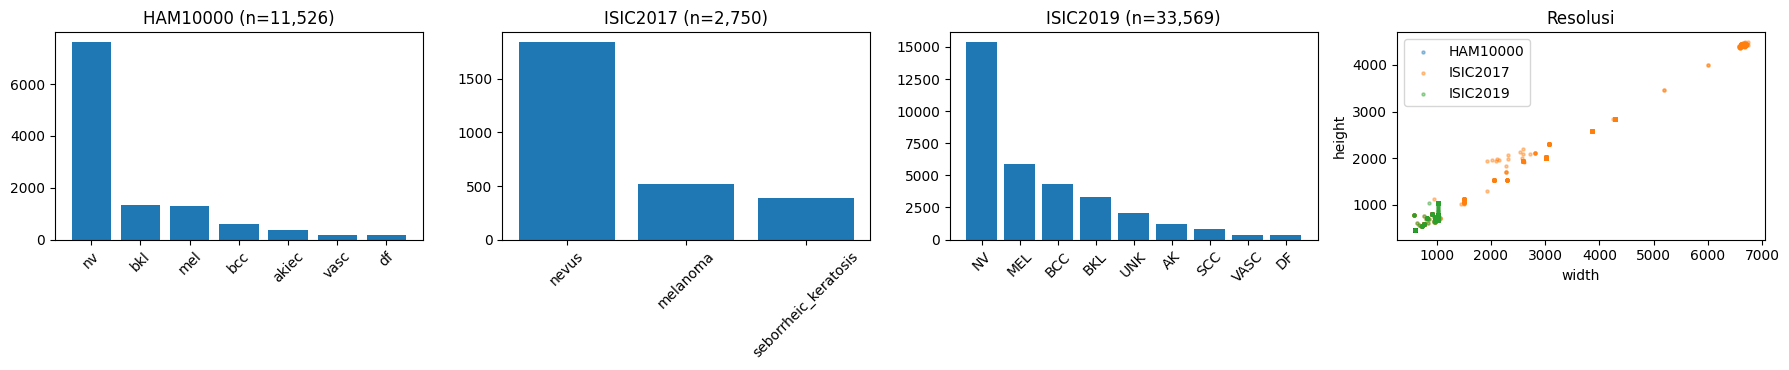

In [4]:
img = master[master.has_image]; ok = img[~img.is_corrupt].reset_index(drop=True)   # ok = citra yang bisa dibuka
A["counts"] = master.groupby(["dataset", "source_split"]).agg(rows=("image_id", "size"), unique_id=("image_id", "nunique"),
    with_image=("has_image", "sum"), with_label=("has_label", "sum"), corrupt=("is_corrupt", "sum"), n_classes=("diagnosis_original", "nunique")).reset_index()
A["missing_meta_pct"] = master.groupby("dataset")[["lesion_id", "diagnosis_original", "age", "sex", "anatom_site"]].agg(lambda s: s.isna().mean() * 100).round(2)
A["label_without_image"] = master[master.has_label & ~master.has_image]
A["image_without_label"] = master[master.has_image & ~master.has_label]
A["corrupt"] = master[master.is_corrupt]
A["odd_labels"] = master[master.diagnosis_original.astype(str).str.startswith("__")]
A["resolution"] = (ok.assign(res=ok.width.astype(int).astype(str) + "x" + ok.height.astype(int).astype(str))
                   .groupby(["dataset", "res"]).size().rename("n").reset_index().sort_values(["dataset", "n"], ascending=[True, False]))
A["format"] = img.groupby(["dataset", "image_format", "color_mode"], dropna=False).size().rename("n").reset_index()
A["class_dist"] = master[master.has_label & master.has_image].groupby(["dataset", "source_split", "diagnosis_original"]).size().rename("n").reset_index()
pl = img.dropna(subset=["lesion_id"]).groupby(["dataset", "lesion_id"]).size()
A["lesion_id"] = (img.groupby("dataset").agg(n_image=("image_id", "size"), with_lesion_id=("lesion_id", lambda s: s.notna().sum()), unique_lesion=("lesion_id", "nunique"))
                  .join(pl[pl > 1].groupby(level=0).size().rename("lesion_gt1_image")).join(pl.groupby(level=0).max().rename("max_img_per_lesion")).reset_index())
for n in ["counts", "missing_meta_pct", "lesion_id"]: print(f"\n== {n}"); display(A[n])
for n in ["label_without_image", "image_without_label", "corrupt", "odd_labels"]: print(f"{n}: {len(A[n])}")
display(A["class_dist"].pivot_table(index="diagnosis_original", columns=["dataset", "source_split"], values="n", fill_value=0))
display(A["resolution"].groupby("dataset").head(5)); display(A["format"])

fig, ax = plt.subplots(1, 4, figsize=(18, 3.8))
for a, (ds, d) in zip(ax, master[master.has_label & master.has_image].groupby("dataset")):
    vc = d.diagnosis_original.value_counts(); a.bar(vc.index.astype(str), vc.values); a.set_title(f"{ds} (n={len(d):,})"); a.tick_params(axis="x", rotation=45)
for ds, d in ok.groupby("dataset"): ax[3].scatter(d.width, d.height, s=5, alpha=.4, label=ds)
ax[3].set(xlabel="width", ylabel="height", title="Resolusi"); ax[3].legend(); fig.tight_layout(); fig.savefig(OUT / "figures/audit.png", dpi=130); plt.show()

## 3. Fase 3 — Duplikat level 1 & 2: `image_id` dan file identik (MD5 + SHA-256)

In [5]:
ids = ok.groupby("base_id").agg(n=("dataset", "size"), datasets=("dataset", lambda s: " & ".join(sorted(set(s)))), n_sha=("sha256", "nunique"))
A["dup_image_id"] = ids[ids.n > 1].assign(same_content=lambda d: d.n_sha == 1).reset_index()
print("Level 1 — image_id muncul >1 kali:"); display(A["dup_image_id"].groupby(["datasets", "same_content"]).size().rename("n_id").reset_index())
diff = ids[(ids.n > 1) & (ids.n_sha > 1)].index          # image_id sama, isi file beda: gambar yang sama (di-resize) atau bukan?
if len(diff):
    x = ok[ok.base_id.isin(diff)].sort_values(["base_id", "dataset", "image_id"]); f, l = x.groupby("base_id").head(1), x.groupby("base_id").tail(1)
    dist = pd.Series(np.array([bin(int(a, 16) ^ int(b, 16)).count("1") for a, b in zip(f.phash, l.phash)]))
    print(f"id dasar sama, isi beda: {len(diff)} id | jarak pHash antar versi: median={dist.median():.0f}, <=4: {(dist <= 4).mean():.0%}, <=10: {(dist <= 10).mean():.0%}")
    display(pd.concat([f[["dataset"]].reset_index(drop=True), l[["dataset"]].reset_index(drop=True)], axis=1).set_axis(["dataset_a", "dataset_b"], axis=1).value_counts().rename("n").reset_index())
sz, mz = ok.groupby("sha256").image_id.transform("size"), ok.groupby("md5").image_id.transform("size")
print(f"Level 2 — file identik: SHA-256={int((sz > 1).sum())} | MD5={int((mz > 1).sum())} | hanya salah satu={int(((sz > 1) != (mz > 1)).sum())}")
A["exact_dup"] = ok[(sz > 1) | (mz > 1)].sort_values("sha256")[["sha256", "md5", "dataset", "source_split", "image_id", "lesion_id", "diagnosis_original", "image_path"]]
display(A["exact_dup"].groupby("sha256").agg(n=("dataset", "size"), datasets=("dataset", lambda s: " & ".join(sorted(set(s))))).groupby("datasets").size().rename("n_grup"))

Level 1 — image_id muncul >1 kali:


,datasets,same_content,n_id
0,HAM10000 & ISIC2019,True,11526
1,ISIC2017 & ISIC2019,False,2025
2,ISIC2017 & ISIC2019,True,720


id dasar sama, isi beda: 2025 id | jarak pHash antar versi: median=0, <=4: 100%, <=10: 100%


,dataset_a,dataset_b,n
0,ISIC2017,ISIC2019,2025


Level 2 — file identik: SHA-256=24600 | MD5=24600 | hanya salah satu=0


datasets
HAM10000 & ISIC2019    11524
ISIC2017                   6
ISIC2017 & ISIC2019      720
ISIC2019                  48
Name: n_grup, dtype: int64

## 4. Fase 3 — Level 3: near-duplicate (pHash)
Hanya **kandidat** untuk diperiksa mata. Hash 64-bit dipecah jadi 8 blok 8-bit; jarak ≤ 7 pasti punya satu blok identik, jadi hanya pasangan satu bucket yang dibandingkan.

pasangan pHash<=4: 19,935 | file identik: 12,308 | image_id sama: 2,025 | KANDIDAT baru: 5,602 (lesion_id sama: 781)


,dataset_1,dataset_2,n_pasangan
0,HAM10000,HAM10000,514
1,HAM10000,ISIC2017,177
2,HAM10000,ISIC2019,1351
3,ISIC2017,ISIC2017,47
4,ISIC2017,ISIC2019,331
5,ISIC2019,ISIC2019,3182


phash_dist,0,2,4
n,126,920,4556


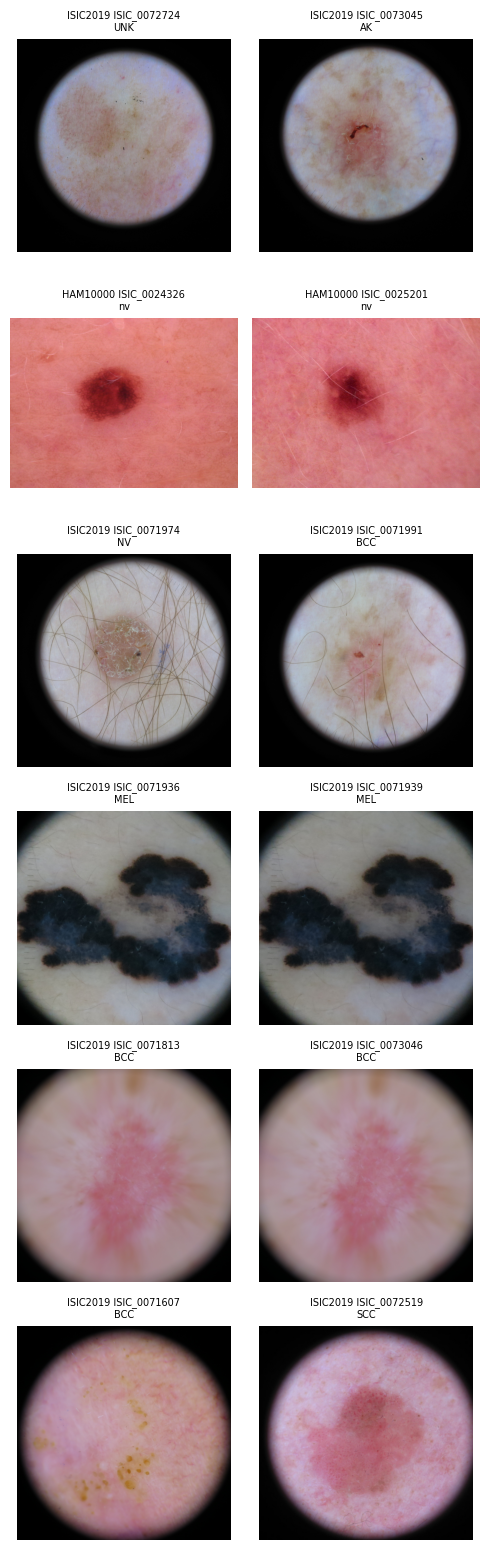

In [6]:
assert PHASH_MAX <= 7
ph, dh = (np.array([int(x, 16) for x in ok[c]], dtype=np.uint64) for c in ["phash", "dhash"])
def pop(x):
    x = x - ((x >> np.uint64(1)) & np.uint64(0x5555555555555555))
    x = (x & np.uint64(0x3333333333333333)) + ((x >> np.uint64(2)) & np.uint64(0x3333333333333333))
    return (((x + (x >> np.uint64(4))) & np.uint64(0x0F0F0F0F0F0F0F0F)) * np.uint64(0x0101010101010101) >> np.uint64(56)).astype(int)

pairs = set()
for b in range(8):
    key = ((ph >> np.uint64(8 * b)) & np.uint64(255)).astype(np.int64); order = np.argsort(key, kind="stable")
    for idx in np.split(order, np.flatnonzero(np.diff(key[order])) + 1):
        for s in range(0, len(idx), 1024):
            a = idx[s:s + 1024]; ai, bi = np.nonzero(pop(ph[a][:, None] ^ ph[idx][None, :]) <= PHASH_MAX)
            pairs.update((int(i), int(j)) for i, j in zip(a[ai], idx[bi]) if i < j)
P = np.array(sorted(pairs), dtype=int).reshape(-1, 2)
dp, dd = pop(ph[P[:, 0]] ^ ph[P[:, 1]]), pop(dh[P[:, 0]] ^ dh[P[:, 1]])
if DHASH_MAX is not None: m = dd <= DHASH_MAX; P, dp, dd = P[m], dp[m], dd[m]
c = ["dataset", "source_split", "image_id", "base_id", "lesion_id", "diagnosis_original", "sha256", "image_path"]
pt = pd.concat([ok.loc[P[:, 0], c].add_suffix("_1").reset_index(drop=True), ok.loc[P[:, 1], c].add_suffix("_2").reset_index(drop=True)], axis=1).assign(phash_dist=dp, dhash_dist=dd)
pt["exact"], pt["same_id"], pt["same_lesion"] = pt.sha256_1 == pt.sha256_2, pt.base_id_1 == pt.base_id_2, (pt.lesion_id_1 == pt.lesion_id_2) & pt.lesion_id_1.notna()
A["near_dup_pairs"] = pt; near = pt[~pt.exact & ~pt.same_id]   # kandidat baru: bukan file identik dan bukan image_id yang sama
print(f"pasangan pHash<={PHASH_MAX}: {len(pt):,} | file identik: {int(pt.exact.sum()):,} | image_id sama: {int((pt.same_id & ~pt.exact).sum()):,} | KANDIDAT baru: {len(near):,} (lesion_id sama: {int(near.same_lesion.sum()):,})")
if len(near):
    display(near.groupby(["dataset_1", "dataset_2"]).size().rename("n_pasangan").reset_index()); display(near.phash_dist.value_counts().sort_index().to_frame("n").T)
    top = near.sort_values("phash_dist", ascending=False).head(6)   # cek visual: pasangan terjauh masih gambar yang sama?
    fig, ax = plt.subplots(len(top), 2, figsize=(5, 2.6 * len(top)), squeeze=False)
    for r, (_, w) in enumerate(top.iterrows()):
        for j in (0, 1): ax[r][j].imshow(Image.open(w[f"image_path_{j + 1}"]).convert("RGB")); ax[r][j].axis("off"); ax[r][j].set_title(f"{w[f'dataset_{j + 1}']} {w[f'image_id_{j + 1}']}\n{w[f'diagnosis_original_{j + 1}']}", fontsize=7)
    fig.tight_layout(); fig.savefig(OUT / "figures/near_dup_pairs.png", dpi=110); plt.show()

## 5. Grup duplikat dan usulan citra yang dipertahankan
Grup = gabungan MD5/SHA-256 sama dan `image_id` dasar sama (nama tanpa sufiks `_downsampled`; union-find). Kandidat pHash **tidak** digabung kecuali `NEAR_MERGE = True`, karena pHash ambang longgar membuat rantai palsu (foto dermoskopi berbingkai hitam saling mirip). Label dinormalkan **hanya** untuk mendeteksi konflik, bukan harmonisasi Fase 5. `proposed_keep` hanyalah usulan.

In [7]:
par = list(range(len(ok)))
def find(x):
    while par[x] != x: par[x] = par[par[x]]; x = par[x]
    return x
def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb: par[max(ra, rb)] = min(ra, rb)
for col in ["sha256", "md5", "base_id"]:
    for idx in ok.groupby(col).indices.values(): [union(int(idx[0]), int(i)) for i in idx[1:]]
if NEAR_MERGE:
    for i, j in P: union(int(i), int(j))
ok["root"] = [find(i) for i in range(len(ok))]
d = ok[ok.groupby("root").root.transform("size") > 1].copy(); d["dup_group_id"] = d.root.rank(method="dense").astype(int)
g = d.groupby("dup_group_id"); d["dup_level"] = np.where(g.sha256.transform("nunique") < g.sha256.transform("size"), "exact", np.where(g.base_id.transform("nunique") < g.base_id.transform("size"), "same_id", "near"))
NORM = {"nv": "nv", "nevus": "nv", "mel": "mel", "melanoma": "mel", "bkl": "bkl", "seborrheic_keratosis": "bkl", "bcc": "bcc",
        "akiec": "akiec", "ak": "akiec", "scc": "scc", "vasc": "vasc", "df": "df", "unk": "unk"}
d["label_norm"] = d.diagnosis_original.astype(str).str.lower().map(NORM)
A["dup_groups"] = d.groupby("dup_group_id").agg(size=("image_id", "size"), level=("dup_level", "first"), datasets=("dataset", lambda s: " & ".join(sorted(set(s)))),
    labels=("label_norm", lambda s: ",".join(sorted(set(s.dropna())))), n_labels=("label_norm", lambda s: s.dropna().nunique()),
    lesion_ids=("lesion_id", lambda s: ",".join(sorted(set(s.dropna().astype(str)))))).assign(label_conflict=lambda x: x.n_labels > 1)
d["needs_review"] = d.dup_group_id.map(A["dup_groups"].label_conflict)
d = d.assign(_p=d.dataset.map({k: i for i, k in enumerate(PRIORITY)}).fillna(99), _s=d.source_split.map({"train": 0, "validation": 1, "test": 2}).fillna(3),
             _l=d.lesion_id.isna(), _a=-(d.width * d.height)).sort_values(["dup_group_id", "_p", "_s", "_l", "_a", "image_id"])
d["proposed_keep"] = ~d.duplicated("dup_group_id")
A["dup_detail"] = d.drop(columns=["root", "_p", "_s", "_l", "_a"])
print(f"grup terbesar: {int(A['dup_groups']['size'].max())} citra | grup >10 citra: {int((A['dup_groups']['size'] > 10).sum())} (grup besar = curiga rantai palsu)")
print(f"grup duplikat: {len(A['dup_groups'])} | citra terlibat: {len(d)} | akan dibuang jika usulan diterapkan: {int((~d.proposed_keep).sum())} | konflik label: {int(A['dup_groups'].label_conflict.sum())}")
display(A["dup_groups"].groupby(["level", "datasets"]).size().rename("n_grup").reset_index()); display(A["dup_groups"][A["dup_groups"].label_conflict].head(20))
flags = master.merge(d[["image_path", "dup_group_id", "dup_level", "proposed_keep", "needs_review"]], on="image_path", how="left")
flags["proposed_keep"] = flags.proposed_keep.astype("boolean").fillna(True).astype(bool); flags.to_csv(OUT / "master_dedup_flags.csv", index=False)
base = flags[flags.has_image & ~flags.is_corrupt]
display(pd.DataFrame({"sebelum": base.groupby("dataset").size(), "sesudah": base[base.proposed_keep].groupby("dataset").size()}).fillna(0).astype(int))

grup terbesar: 4 citra | grup >10 citra: 0 (grup besar = curiga rantai palsu)
grup duplikat: 14315 | citra terlibat: 28641 | akan dibuang jika usulan diterapkan: 14326 | konflik label: 223


,level,datasets,n_grup
0,exact,HAM10000 & ISIC2019,11524
1,exact,ISIC2017 & ISIC2019,726
2,exact,ISIC2019,47
3,same_id,ISIC2017 & ISIC2019,2018


,size,level,datasets,labels,n_labels,lesion_ids,label_conflict
dup_group_id,,,,,,,
24,2,exact,HAM10000 & ISIC2019,"akiec,scc",2,HAM_0002954,True
67,2,exact,HAM10000 & ISIC2019,"akiec,scc",2,HAM_0005389,True
113,2,exact,HAM10000 & ISIC2019,"akiec,scc",2,HAM_0003380,True
145,2,exact,HAM10000 & ISIC2019,"akiec,scc",2,HAM_0005505,True
158,2,exact,HAM10000 & ISIC2019,"akiec,scc",2,HAM_0004568,True
212,2,exact,HAM10000 & ISIC2019,"akiec,scc",2,HAM_0001894,True
217,2,exact,HAM10000 & ISIC2019,"akiec,scc",2,HAM_0005650,True
234,2,exact,HAM10000 & ISIC2019,"akiec,scc",2,HAM_0002551,True
257,2,exact,HAM10000 & ISIC2019,"akiec,scc",2,HAM_0002745,True


,sebelum,sesudah
dataset,,
HAM10000,11526,11524
ISIC2017,2750,0
ISIC2019,33569,21995


## 6. Simpan hasil

In [8]:
for n, t in A.items(): t.to_csv(OUT / f"audit_{n}.csv", index=n in ("missing_meta_pct", "dup_groups"))
summary = {"images_in_master": len(master), "with_image": int(master.has_image.sum()), "corrupt": int(master.is_corrupt.sum()),
           "label_without_image": len(A["label_without_image"]), "image_without_label": len(A["image_without_label"]),
           "dup_image_id": len(A["dup_image_id"]), "exact_dup_files": len(A["exact_dup"]), "near_candidates": len(near), "exact_extra_copies": int(ok.duplicated("sha256").sum()),
           "thresholds": {"phash_max": PHASH_MAX, "dhash_max": DHASH_MAX, "near_merge": NEAR_MERGE}, "dup_groups": len(A["dup_groups"]),
           "proposed_removed": int((~d.proposed_keep).sum()), "label_conflict_groups": int(A["dup_groups"].label_conflict.sum()),
           "per_dataset": {k: {"rows": len(v), "with_image": int(v.has_image.sum()), "classes": v.diagnosis_original.value_counts().to_dict()} for k, v in master.groupby("dataset")}}
json.dump(summary, open(OUT / "audit_dedup_summary.json", "w"), indent=2, default=str); print(json.dumps(summary, indent=2, default=str)); print("Output:", OUT)

{
  "images_in_master": 47846,
  "with_image": 47845,
  "corrupt": 0,
  "label_without_image": 1,
  "image_without_label": 0,
  "dup_image_id": 14271,
  "exact_dup_files": 24600,
  "near_candidates": 5602,
  "exact_extra_copies": 12302,
  "thresholds": {
    "phash_max": 4,
    "dhash_max": null,
    "near_merge": false
  },
  "dup_groups": 14315,
  "proposed_removed": 14326,
  "label_conflict_groups": 223,
  "per_dataset": {
    "HAM10000": {
      "rows": 11527,
      "with_image": 11526,
      "classes": {
        "nv": 7614,
        "bkl": 1316,
        "mel": 1284,
        "bcc": 607,
        "akiec": 370,
        "vasc": 177,
        "df": 159
      }
    },
    "ISIC2017": {
      "rows": 2750,
      "with_image": 2750,
      "classes": {
        "nevus": 1843,
        "melanoma": 521,
        "seborrheic_keratosis": 386
      }
    },
    "ISIC2019": {
      "rows": 33569,
      "with_image": 33569,
      "classes": {
        "NV": 15370,
        "MEL": 5849,
        "BCC": 429